In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing
from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Model Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Train / Validation Split
from sklearn.model_selection import train_test_split

# Reproducibility
import random

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Random Seeds
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow Version: 2.20.0
Libraries imported successfully!


In [2]:
DATA_DIR = "/kaggle/input/datasets/pranavraikokte/covid19-image-dataset/Covid19-dataset"

print("Classes:")
for folder in os.listdir(DATA_DIR):
    path = os.path.join(DATA_DIR, folder)
    if os.path.isdir(path):
        print(f"{folder}: {len(os.listdir(path))} images")

Classes:
test: 3 images
train: 3 images


In [3]:
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("===== TRAIN DATA =====")
for folder in os.listdir(TRAIN_DIR):
    path = os.path.join(TRAIN_DIR, folder)
    if os.path.isdir(path):
        print(f"{folder}: {len(os.listdir(path))} images")

print("\n===== TEST DATA =====")
for folder in os.listdir(TEST_DIR):
    path = os.path.join(TEST_DIR, folder)
    if os.path.isdir(path):
        print(f"{folder}: {len(os.listdir(path))} images")

===== TRAIN DATA =====
Normal: 70 images
Viral Pneumonia: 70 images
Covid: 111 images

===== TEST DATA =====
Normal: 20 images
Viral Pneumonia: 20 images
Covid: 26 images


In [4]:
# ==========================================
# Correct Data Generators
# ==========================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Training: Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

# Validation: NO augmentation
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

# Test: NO augmentation
test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_generator = validation_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Train:", train_generator.samples)
print("Validation:", validation_generator.samples)
print("Test:", test_generator.samples)
print("Classes:", train_generator.class_indices)

Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Found 66 images belonging to 3 classes.
Train: 201
Validation: 50
Test: 66
Classes: {'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}


In [5]:
model = Sequential([
    
    layers.Conv2D(32, (3, 3), activation="relu",
                  padding="same", input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu",
                  padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu",
                  padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1786716872.168368      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786716872.171822      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,595 (400.76 KB)

 Trainable params: 102,147 (399.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Model compiled successfully!")

Model compiled successfully!


In [7]:
EPOCHS = 30

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/30
 1/13 ━━━━━━━━━━━━━━━━━━━━ 1:47 9s/step - accuracy: 0.1250 - loss: 1.5746

I0000 00:00:1786716883.863852      93 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6269 - loss: 0.8090 - val_accuracy: 0.4400 - val_loss: 1.0733 - learning_rate: 0.0010
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 515ms/step - accuracy: 0.7264 - loss: 0.6039 - val_accuracy: 0.4400 - val_loss: 1.1045 - learning_rate: 0.0010
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 509ms/step - accuracy: 0.7114 - loss: 0.6094 - val_accuracy: 0.4400 - val_loss: 1.2607 - learning_rate: 0.0010
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.8144 - loss: 0.5347
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 541ms/step - accuracy: 0.7960 - loss: 0.5225 - val_accuracy: 0.4400 - val_loss: 1.3916 - learning_rate: 0.0010
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 530ms/step - accuracy: 0.8060 - loss: 0.4783 - val_accuracy: 0.4400 - val_loss: 1.5625 - learning_rate: 5.0000e-04
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 505ms/step - accuracy: 0.7662 - loss: 0.5497 - val_accura

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Reset generator
validation_generator.reset()

# Predictions
y_pred_prob = model.predict(validation_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = validation_generator.classes

# Class names
class_names = list(validation_generator.class_indices.keys())

print("Class Names:")
print(class_names)

print("\nPredicted Distribution:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {(y_pred == i).sum()}")

print("\nActual Distribution:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {(y_true == i).sum()}")

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step
Class Names:
['Covid', 'Normal', 'Viral Pneumonia']

Predicted Distribution:
Covid: 50
Normal: 0
Viral Pneumonia: 0

Actual Distribution:
Covid: 22
Normal: 14
Viral Pneumonia: 14

Classification Report:
                 precision    recall  f1-score   support

          Covid       0.44      1.00      0.61        22
         Normal       0.00      0.00      0.00        14
Viral Pneumonia       0.00      0.00      0.00        14

       accuracy                           0.44        50
      macro avg       0.15      0.33      0.20        50
   weighted avg       0.19      0.44      0.27        50


Confusion Matrix:
[[22  0  0]
 [14  0  0]
 [14  0  0]]


In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(zip(classes, class_weights))

print("Class Weights:")
for class_id, weight in class_weights.items():
    print(f"{class_names[class_id]}: {weight:.4f}")

Class Weights:
Covid: 0.7528
Normal: 1.1964
Viral Pneumonia: 1.1964


In [10]:
# MobileNetV2 Transfer Learning

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

model = Sequential([
    base_model,
    
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(3, activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Training Generator
train_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20,
    
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

# Validation Generator
validation_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.20
)

# Test Generator
test_datagen_mobilenet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen_mobilenet.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

validation_generator = validation_datagen_mobilenet.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

test_generator = test_datagen_mobilenet.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Train:", train_generator.samples)
print("Validation:", validation_generator.samples)
print("Test:", test_generator.samples)
print("Classes:", train_generator.class_indices)

Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Found 66 images belonging to 3 classes.
Train: 201
Validation: 50
Test: 66
Classes: {'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}


In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("MobileNetV2 compiled successfully!")

MobileNetV2 compiled successfully!


In [13]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [14]:
EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/20


2026-08-14 14:16:06.613628: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 14:16:06.766502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 14:16:06.903906: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/13 ━━━━━━━━━━━━━━━━━━━━ 3:25 17s/step - accuracy: 0.3750 - loss: 1.0556

2026-08-14 14:16:18.139863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 14:16:18.276398: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 14:16:18.412354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4183 - loss: 1.2490

2026-08-14 14:16:38.365015: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-14 14:16:38.501486: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.4577 - loss: 1.1628 - val_accuracy: 0.5200 - val_loss: 0.9009 - learning_rate: 1.0000e-04
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 521ms/step - accuracy: 0.5821 - loss: 0.8748 - val_accuracy: 0.7200 - val_loss: 0.7332 - learning_rate: 1.0000e-04
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 515ms/step - accuracy: 0.7313 - loss: 0.6820 - val_accuracy: 0.7200 - val_loss: 0.6797 - learning_rate: 1.0000e-04
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 508ms/step - accuracy: 0.7214 - loss: 0.6667 - val_accuracy: 0.7600 - val_loss: 0.5732 - learning_rate: 1.0000e-04
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 500ms/step - accuracy: 0.7861 - loss: 0.5444 - val_accuracy: 0.8000 - val_loss: 0.4985 - learning_rate: 1.0000e-04
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 514ms/step - accuracy: 0.8010 - loss: 0.5358 - val_accuracy: 0.8200 - val_loss: 0.5365 - learning_rate: 1.0000e-04
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8021 - loss

In [15]:
# Test Evaluation
test_generator.reset()

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.9242 - loss: 0.3384

Test Loss: 0.3384
Test Accuracy: 0.9242
Test Accuracy: 92.42%


In [16]:
# Test Classification Report

from sklearn.metrics import classification_report, confusion_matrix

test_generator.reset()

y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
Classification Report:
                 precision    recall  f1-score   support

          Covid       0.96      1.00      0.98        26
         Normal       1.00      0.80      0.89        20
Viral Pneumonia       0.83      0.95      0.88        20

       accuracy                           0.92        66
      macro avg       0.93      0.92      0.92        66
   weighted avg       0.93      0.92      0.92        66


Confusion Matrix:
[[26  0  0]
 [ 0 16  4]
 [ 1  0 19]]


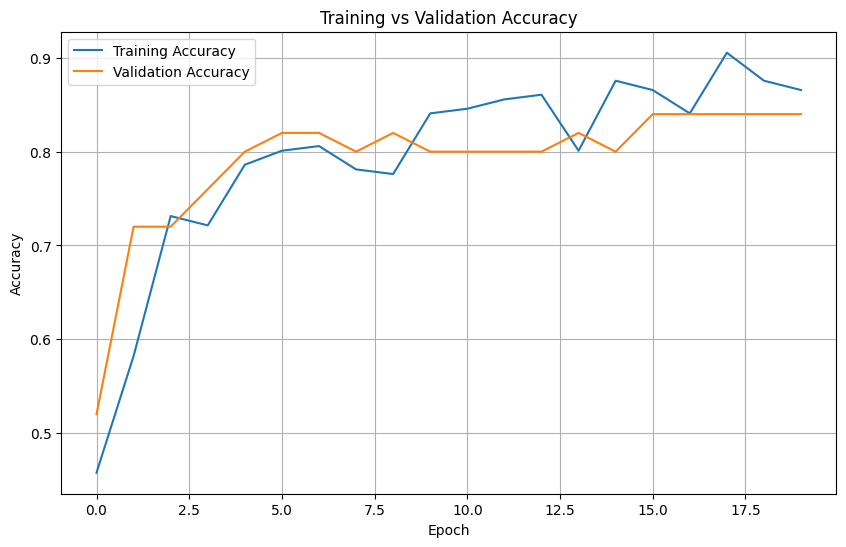

In [17]:
# Training vs Validation Accuracy

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

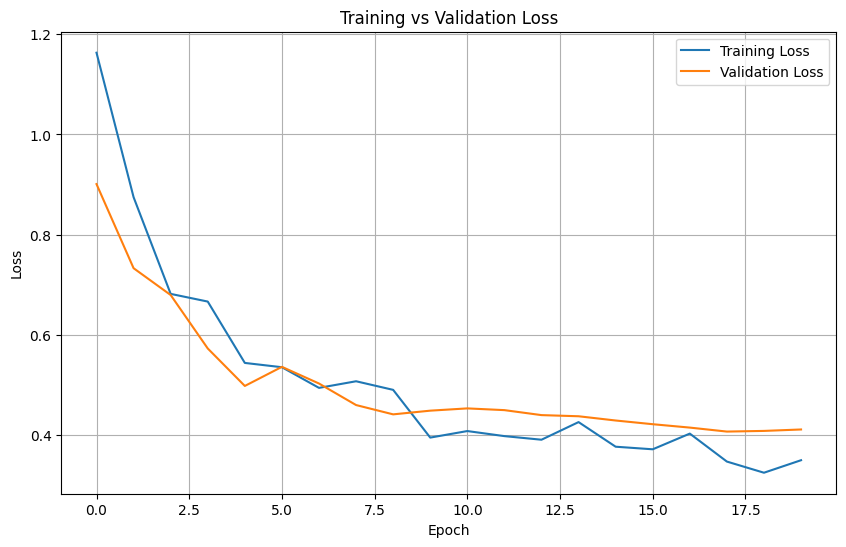

In [18]:
# Training vs Validation Loss
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

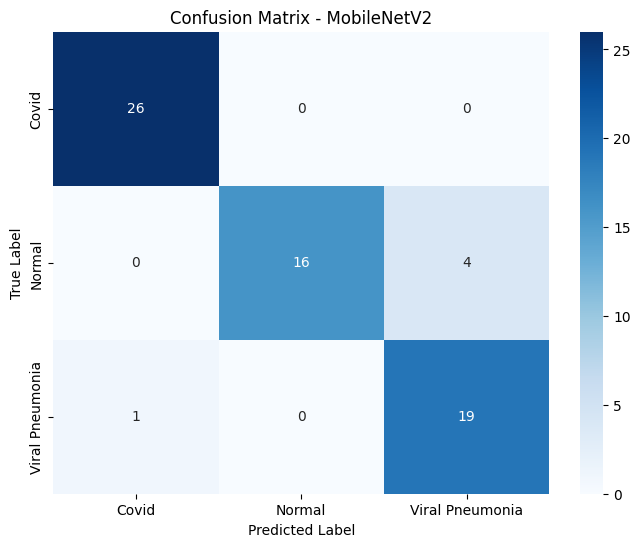

In [19]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - MobileNetV2")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()